# Black–Litterman: Equilibrium + Views

**pyportfolios.com tutorial T06** · EWJ · EWG · EWU · EWA · EWC, Jan 2015 – Dec 2024 · PyPortfolioOpt · NumPy

Mean-variance optimization is famously an *error maximiser*: feed it raw historical
means and it hands back extreme corner portfolios that flip violently when an input
moves by basis points. Black–Litterman fixes the inputs instead of the optimizer. In
this notebook we

1. show the instability on five iShares country ETFs,
2. reverse-optimize **equilibrium returns** from market-cap weights,
3. blend in two explicit views with Idzorek confidences, and
4. verify the posterior weights tilt smoothly — and only where the views say.

In [1]:
# pip install PyPortfolioOpt yfinance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from pypfopt import EfficientFrontier, expected_returns, risk_models
from pypfopt.black_litterman import BlackLittermanModel, market_implied_prior_returns

plt.rcParams["figure.figsize"] = (10, 5)
RF, DELTA = 0.02, 2.5

## 1 · Data: five country ETFs

iShares single-country funds for Japan, Germany, the UK, Australia and Canada —
five developed markets with meaningfully different sector mixes, sharing one decade
(2015–2024) that contains a commodity bust, COVID, and a rate-hiking cycle.

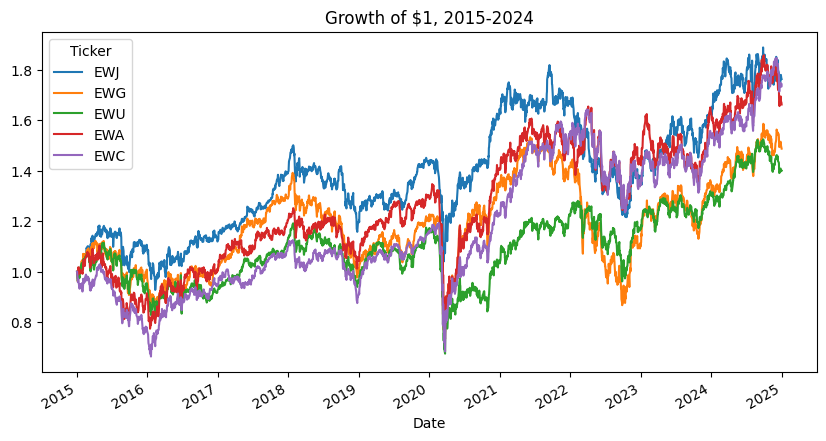

In [2]:
ORDER = ["EWJ", "EWG", "EWU", "EWA", "EWC"]   # JP, DE, UK, AU, CA
px = yf.download(ORDER, start="2015-01-01", end="2025-01-01",
                 auto_adjust=True, progress=False)["Close"][ORDER].dropna()
(px / px.iloc[0]).plot(title="Growth of $1, 2015-2024");

## 2 · MVO on raw historical means — the instability demo

Estimate a Ledoit–Wolf shrunk covariance and plain historical mean returns, then
ask for the max-Sharpe portfolio. Long-only, it parks **zero** in three of the five
countries. Unconstrained ($w = (\delta\Sigma)^{-1}(\mu - r_f)$), it shorts the UK
by ~67%. Then bump one input — the UK mean — by a single percentage point and watch
the whole allocation convulse.

In [3]:
mu_hist = expected_returns.mean_historical_return(px)      # annual CAGR
S = risk_models.CovarianceShrinkage(px).ledoit_wolf()       # annualised

ef = EfficientFrontier(mu_hist, S)
ef.max_sharpe(risk_free_rate=RF)
print("long-only max-Sharpe:", ef.clean_weights())

def unconstrained(mu):
    return pd.Series(np.linalg.solve(DELTA * S.values, mu - RF), index=ORDER)

w_hist = unconstrained(mu_hist.values)
mu_bump = mu_hist.copy(); mu_bump["EWU"] += 0.01            # +100bp to the UK
w_bump = unconstrained(mu_bump.values)

print(pd.DataFrame({"base": w_hist, "+100bp UK": w_bump}).round(3))
print(f"L1 weight shift from a 1pp input change: {(w_bump - w_hist).abs().sum():.2f}")

long-only max-Sharpe: OrderedDict([('EWJ', 0.71736), ('EWG', 0.0), ('EWU', 0.0), ('EWA', 0.0), ('EWC', 0.28264)])
      base  +100bp UK
EWJ  0.697      0.661
EWG -0.128     -0.353
EWU -0.674     -0.111
EWA -0.015     -0.130
EWC  0.647      0.510
L1 weight shift from a 1pp input change: 1.07


## 3 · Reverse optimization: the equilibrium prior

Black–Litterman starts from the portfolio nobody argues with — market-cap weights —
and asks *which returns would make it optimal*: $\Pi = \delta \Sigma w_{mkt} + r_f$.
Market caps below are approximate free-float equity totals (late 2024); only their
*relative* sizes matter.

In [4]:
MCAPS = {
    "EWJ": 6.2e12,   # Japan
    "EWG": 2.1e12,   # Germany
    "EWU": 3.1e12,   # UK
    "EWA": 1.7e12,   # Australia
    "EWC": 2.6e12,   # Canada
}
w_mkt = pd.Series(MCAPS) / sum(MCAPS.values())

prior = market_implied_prior_returns(MCAPS, DELTA, S, risk_free_rate=RF)
print(pd.DataFrame({"w_mkt": w_mkt, "equilibrium": prior}).round(4))

# sanity check: inverting the equilibrium recovers market weights exactly
print(unconstrained(prior.values).round(4))

      w_mkt  equilibrium
EWJ  0.3949       0.0859
EWG  0.1338       0.1002
EWU  0.1975       0.0952
EWA  0.1083       0.1073
EWC  0.1656       0.0923
EWJ    0.3949
EWG    0.1338
EWU    0.1975
EWA    0.1083
EWC    0.1656
dtype: float64


## 4 · Two views, with confidence

Views enter through a picking matrix $P$ and a target vector $Q$:

- **relative** — Japan outperforms Germany by 2%/yr → row `[1, -1, 0, 0, 0]`,
- **absolute** — Australia returns 6%/yr → row `[0, 0, 0, 1, 0]`.

Idzorek's method converts a plain-English confidence (here 30% on each) into the
view-uncertainty matrix $\Omega$, sparing us from guessing its entries directly.

In [5]:
P = np.array([
    [1.0, -1.0, 0.0, 0.0, 0.0],   # Japan beats Germany ...
    [0.0,  0.0, 0.0, 1.0, 0.0],   # Australia returns ...
])
Q = np.array([0.02, 0.06])

bl = BlackLittermanModel(S, pi=prior.values.reshape(-1, 1), P=P, Q=Q,
                         omega="idzorek", view_confidences=[0.30, 0.30],
                         risk_aversion=DELTA, tau=0.05)
post = pd.Series(np.ravel(bl.bl_returns().values), index=ORDER)

pd.DataFrame({"equilibrium": prior, "historical": mu_hist, "posterior": post}).round(4)

,equilibrium,historical,posterior
EWJ,0.0859,0.0585,0.0807
EWG,0.1002,0.0406,0.0831
EWU,0.0952,0.0344,0.0815
EWA,0.1073,0.0523,0.0904
EWC,0.0923,0.0572,0.0799


## 5 · Posterior weights — smooth tilts, not convulsions

Invert the posterior exactly as we inverted the prior. Three things to verify:

1. weights move **in the direction of the views** (long Japan vs Germany, trim Australia),
2. assets that appear in **no view** (UK, Canada) stay at their market weights,
3. hardening a view by the same +100bp moves weights ~10× less than the same bump
   did under raw-mean MVO.

     market  hist MVO  Black-Litterman
EWJ   0.395     0.697            0.567
EWG   0.134    -0.128           -0.038
EWU   0.197    -0.674            0.197
EWA   0.108    -0.015            0.011
EWC   0.166     0.647            0.166
BL L1 shift from +100bp on a view: 0.11


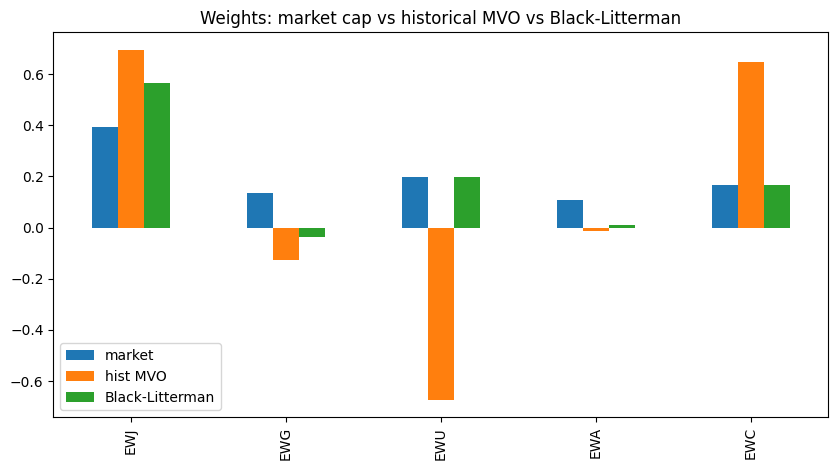

In [6]:
w_bl = unconstrained(post.values)
cmp = pd.DataFrame({"market": w_mkt, "hist MVO": w_hist, "Black-Litterman": w_bl})
print(cmp.round(3))
cmp.plot.bar(title="Weights: market cap vs historical MVO vs Black-Litterman");

# sensitivity of the BL weights to the same +100bp, applied to view 1
bl2 = BlackLittermanModel(S, pi=prior.values.reshape(-1, 1), P=P,
                          Q=np.array([0.03, 0.06]), omega="idzorek",
                          view_confidences=[0.30, 0.30], risk_aversion=DELTA, tau=0.05)
w_bl2 = unconstrained(np.ravel(bl2.bl_returns().values))
print(f"BL L1 shift from +100bp on a view: {(w_bl2 - w_bl).abs().sum():.2f}")

## Takeaways

- Raw historical means hand MVO statistically indistinguishable inputs — it responds
  with corner solutions and violent sensitivity (L1 shift ≈ 1.1 per 1pp input change).
- Reverse optimization gives a prior that is optimal *by construction* at market weights.
- Views are portfolios: relative rows sum to zero, absolute rows pick one asset;
  Idzorek turns "30% confident" into a defensible Ω.
- The posterior tilts only where views act and shrugs at input noise — stable weights
  without extreme bets.

*© pyportfolios.com — runnable companion to the article. Data: Yahoo Finance via yfinance.*